##  Environment Setup & Hardware Verification

In [2]:
!nvidia-smi

Wed Apr  1 15:06:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.0/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

import os

HOME = os.getcwd()
print(HOME)

/content


In [5]:
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.8 MB/s eta 0:00:00


## Dataset Acquisition (Roboflow Integration) 

In [9]:
from roboflow import Roboflow
rf = Roboflow(api_key="eQtTi7KJvF91dvcXWrUF")
project = rf.workspace("chandimas-workspace").project("construction-safety-monitor-mlpd4")
version = project.version(1)
dataset = version.download("yolov8")

print(f"\n✅ Dataset downloaded to: {dataset.location}")
print(f"📁 YAML config: {dataset.location}/data.yaml")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to construction-safety-monitor-1 in yolov8:: 100%|██████████| 24860/24860 [00:05<00:00, 4871.12it/s]



✅ Dataset downloaded to: /content/construction-safety-monitor-1
📁 YAML config: /content/construction-safety-monitor-1/data.yaml


## YOLOv8n Model Initialization & Fine-Tuning

In [10]:
%cd {HOME}

!yolo task=detect \
      mode=train \
      model=yolov8n.pt \
      data={dataset.location}/data.yaml \
      epochs=50 \
      imgsz=640 \
      batch=16 \
      patience=10 \
      project=/content/runs \
      name=safety_monitor_v1 \
      conf=0.45 \
      save=True \
      plots=True

print("\n✅ Training complete!")
print("📦 Best weights: /content/runs/safety_monitor_v1/weights/best.pt")


/content
100% 6.25M/6.25M [00:00<00:00, 37.0MB/s]
New https://pypi.org/project/ultralytics/8.4.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/construction-safety-monitor-1/data.yaml, epochs=50, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/runs, name=safety_monitor_v1, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=0.45, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augmen

##  Evaluation Metrics & Confusion Matrix Analysis

=== Training Results ===


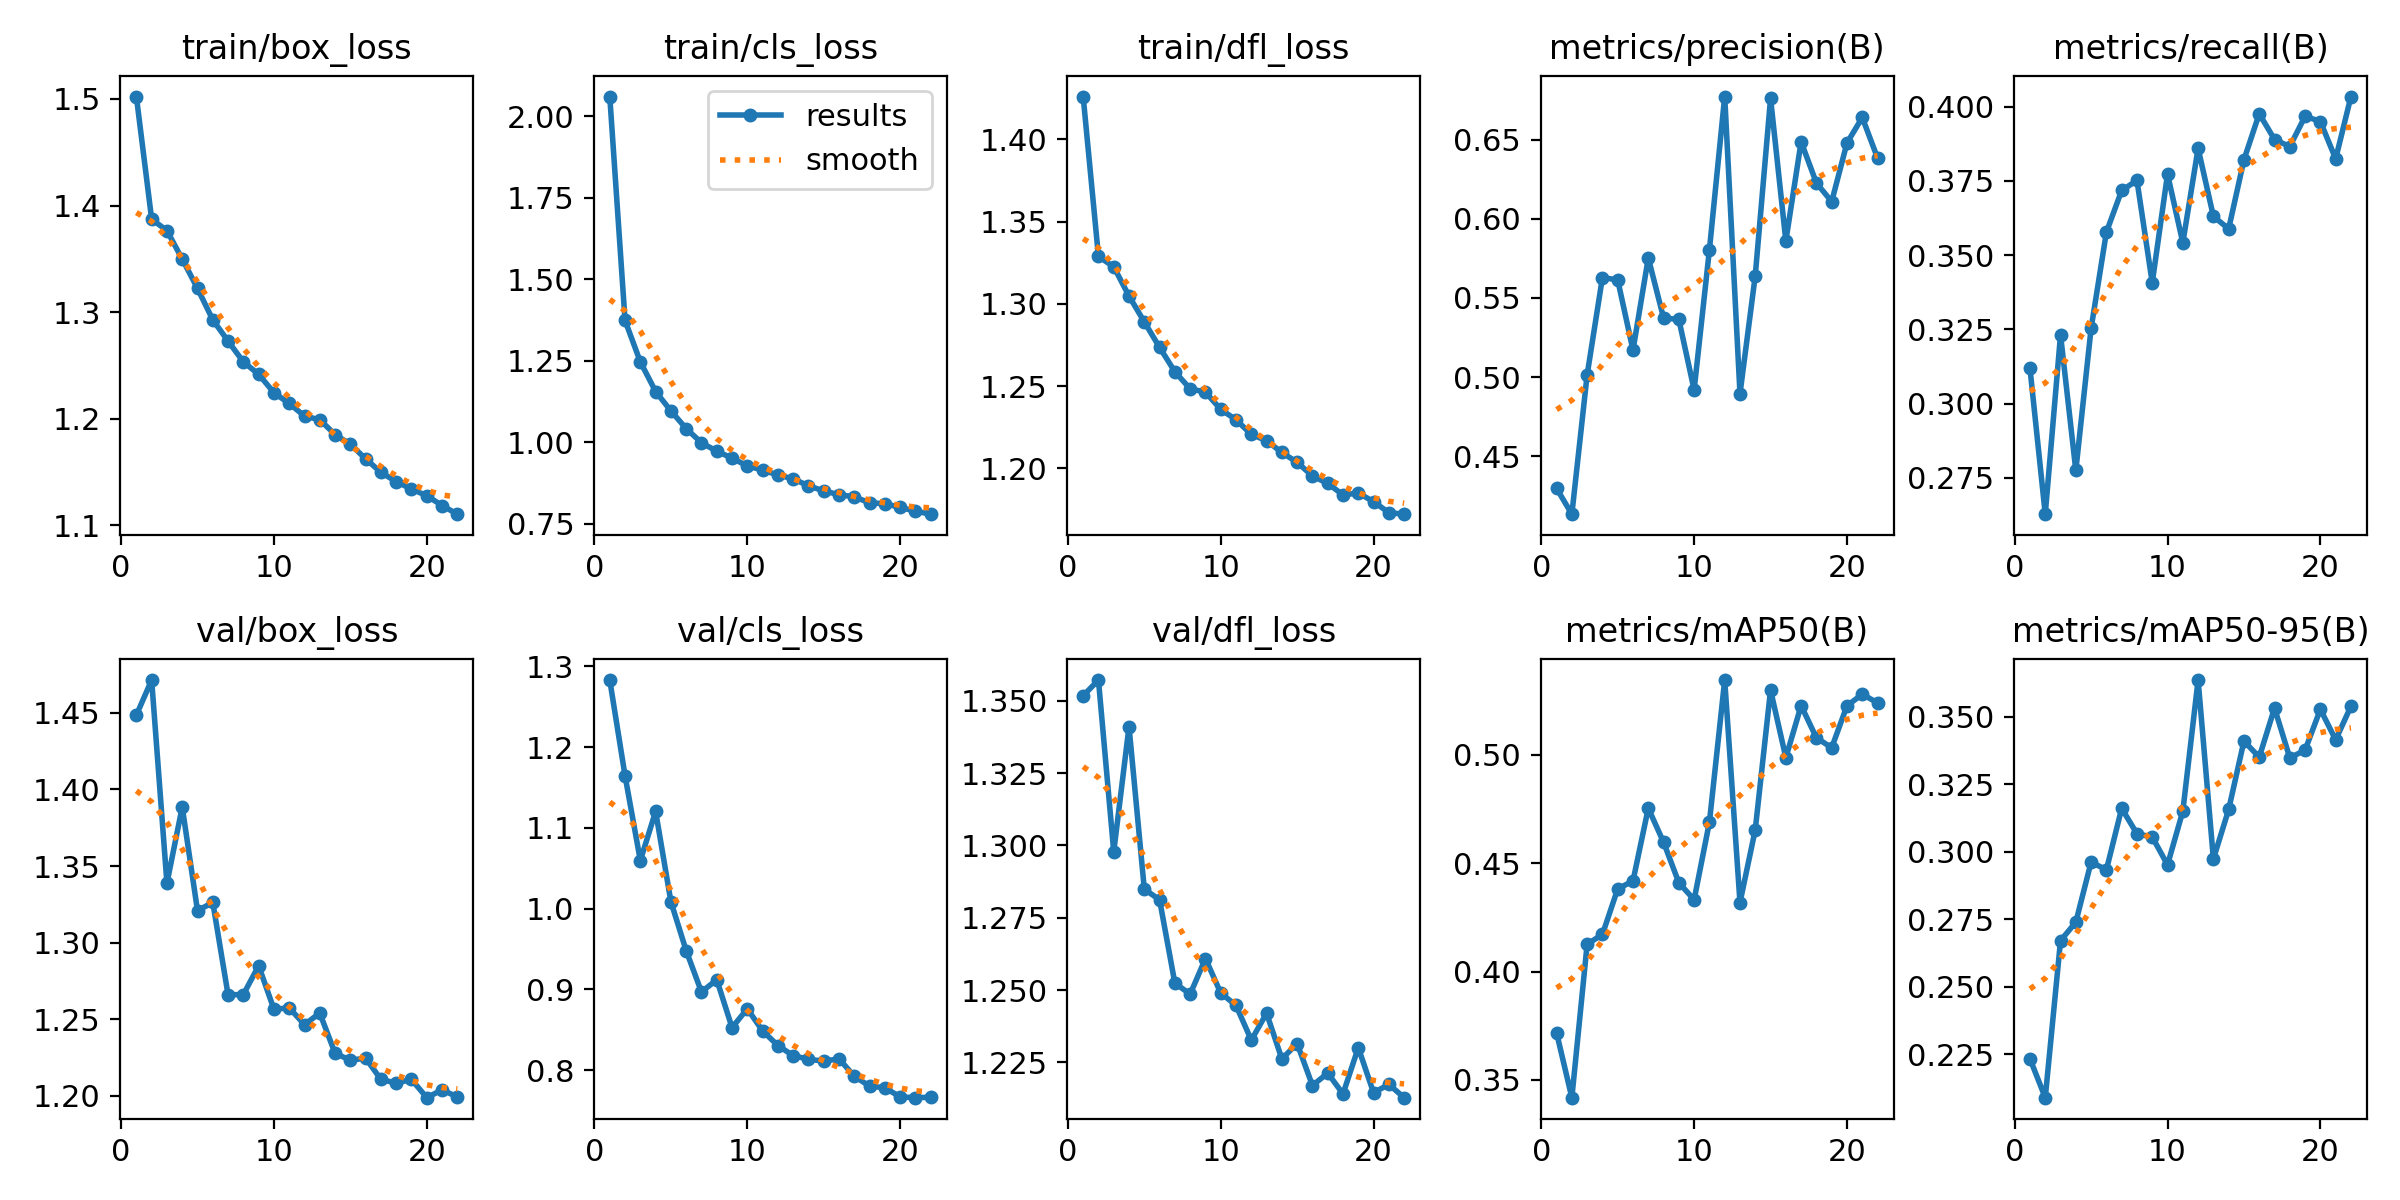

In [11]:
# Show training curves
from IPython.display import Image

print("=== Training Results ===")
Image(filename=f'/content/runs/safety_monitor_v1/results.png', width=800)


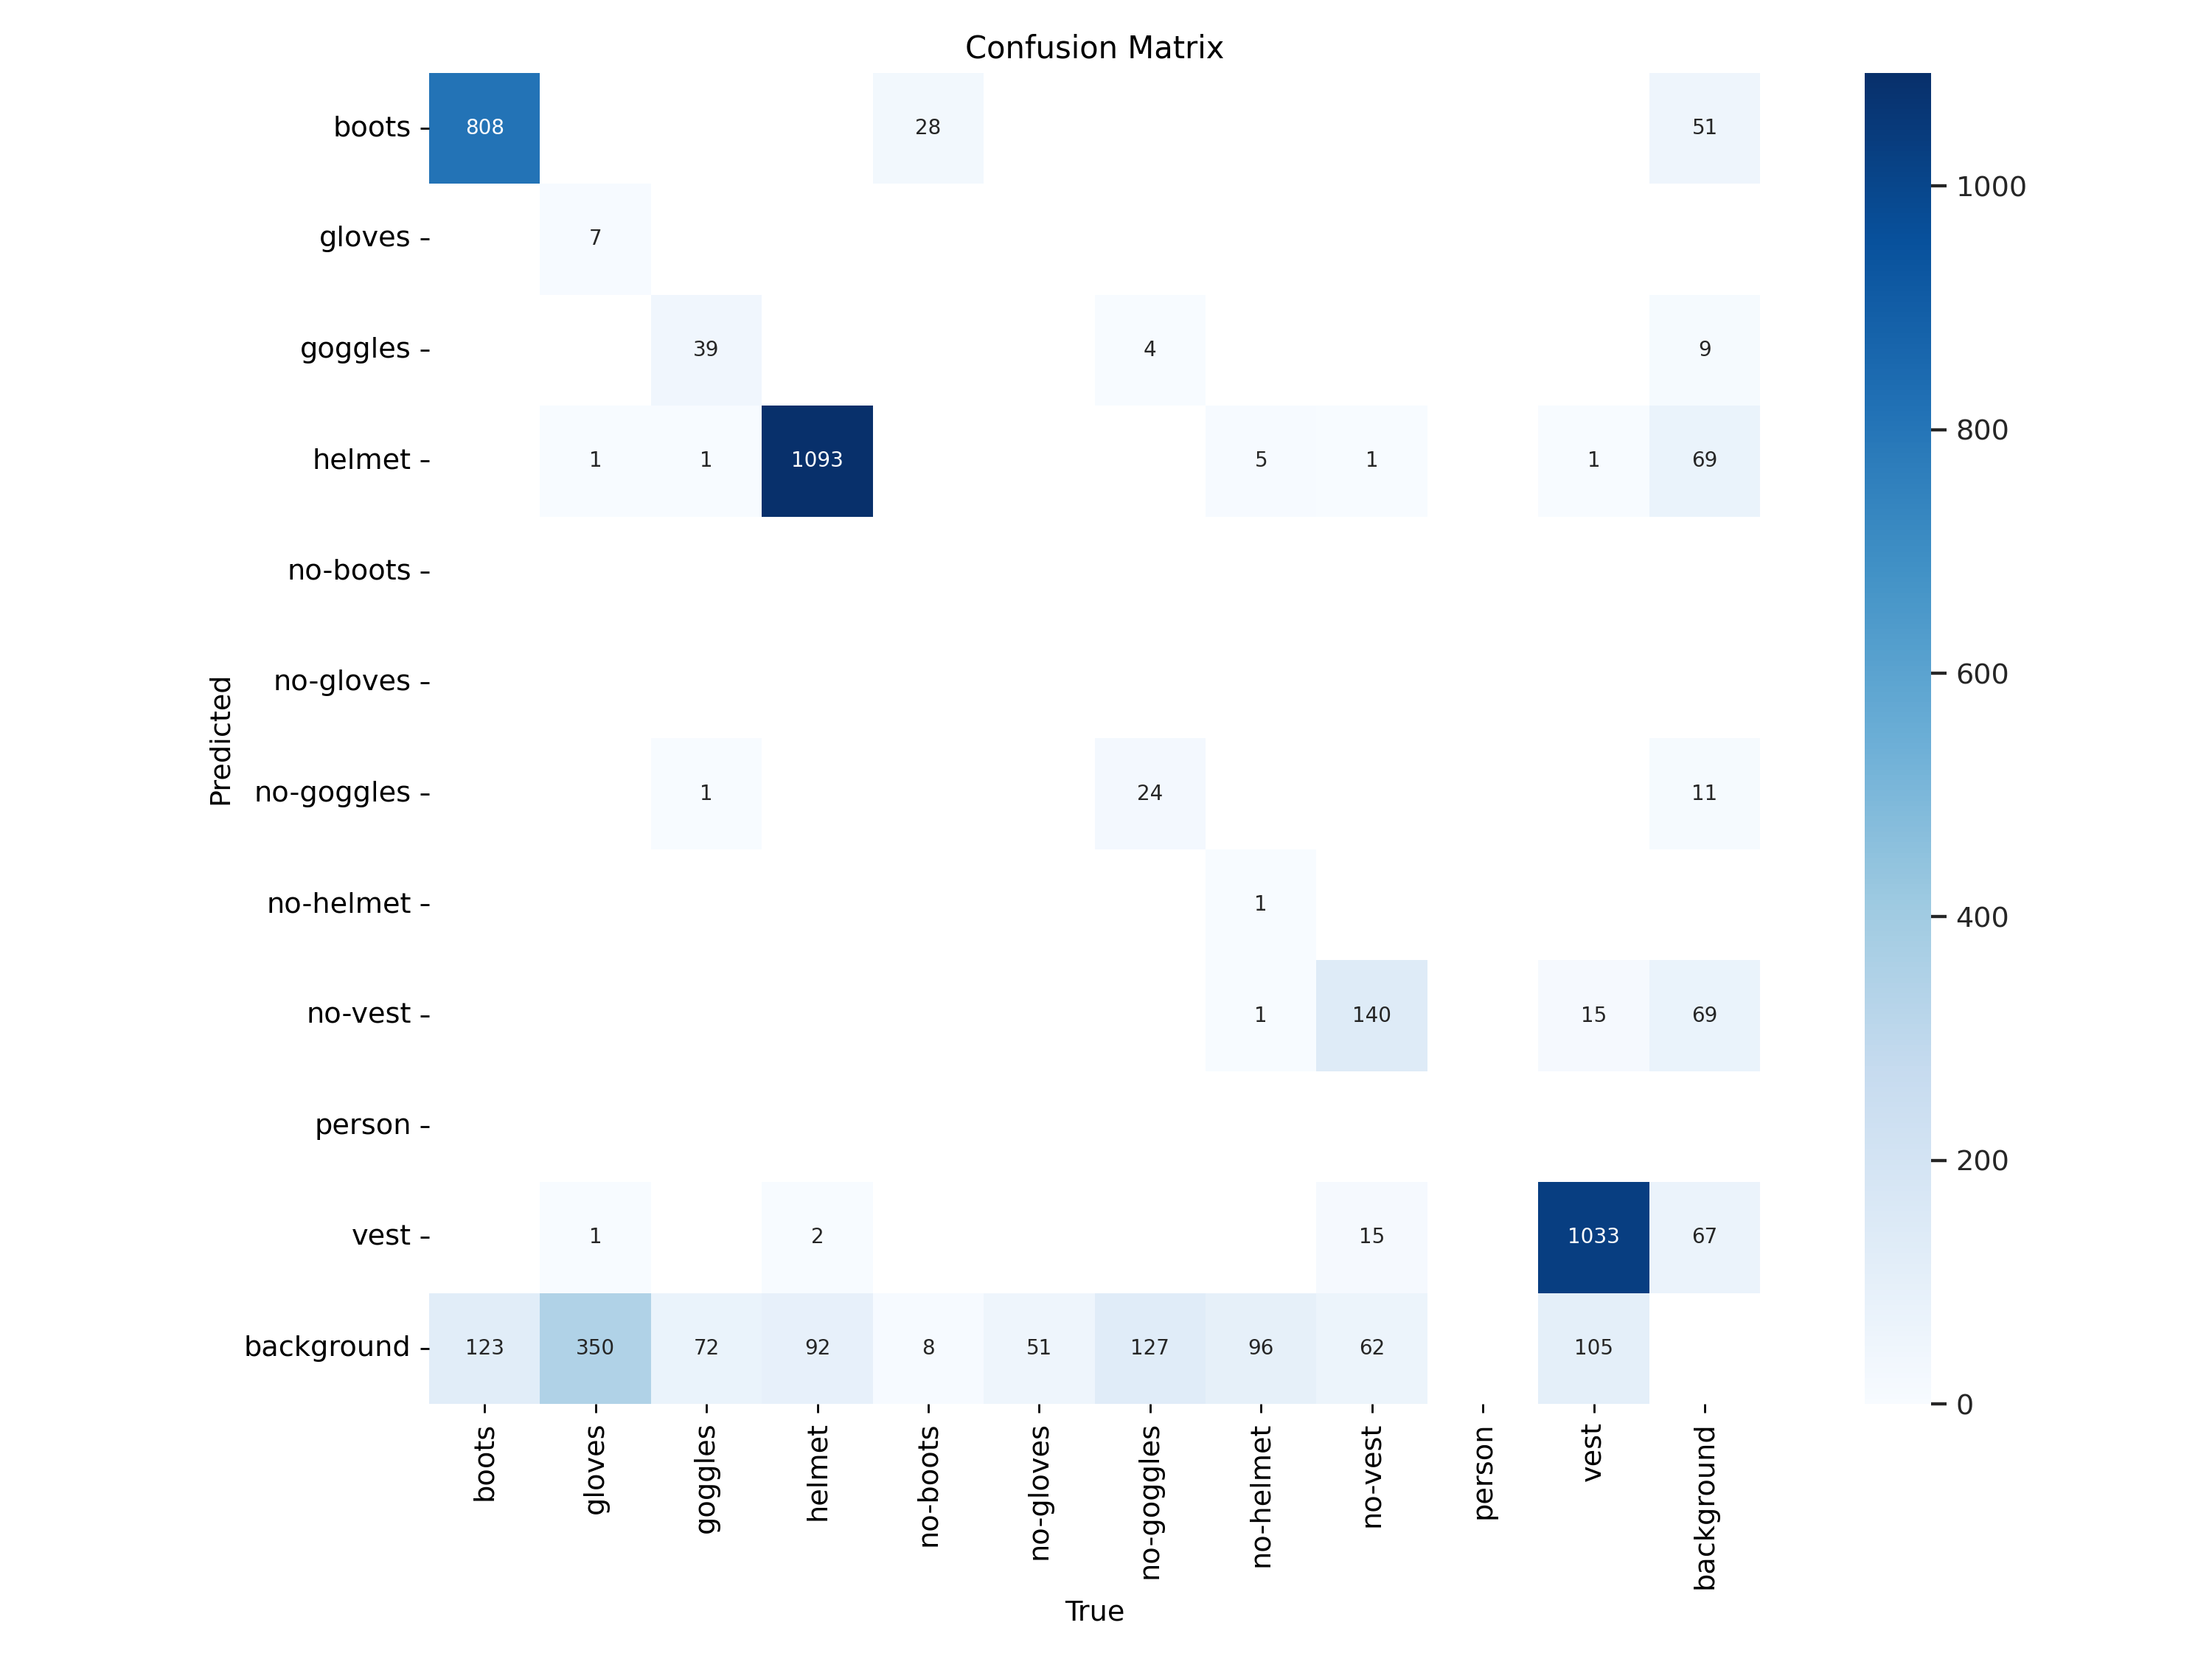

In [12]:
# Show confusion matrix
Image(filename=f'/content/runs/safety_monitor_v1/confusion_matrix.png', width=800)


In [13]:
# Run inference on a test image from the dataset
!yolo task=detect \
      mode=predict \
      model=/content/runs/safety_monitor_v1/weights/best.pt \
      source={dataset.location}/test/images \
      conf=0.45 \
      save=True \
      project=/content/runs \
      name=test_predictions

# Show one prediction
import glob
test_imgs = glob.glob('/content/runs/test_predictions/*.jpg')
if test_imgs:
    Image(filename=test_imgs[0], width=640)


Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs

image 1/517 /content/construction-safety-monitor-1/test/images/00011_jpg.rf.726a74add3da43eab5f0a22b6a175a59.jpg: 640x640 2 vests, 7.2ms
image 2/517 /content/construction-safety-monitor-1/test/images/00048_jpg.rf.48942bff00cf1f7a18272c8754349144.jpg: 640x640 2 helmets, 2 vests, 7.3ms
image 3/517 /content/construction-safety-monitor-1/test/images/00100_jpg.rf.f90cea129fb308bf3a72faaa0e6fae01.jpg: 640x640 1 helmet, 2 vests, 7.2ms
image 4/517 /content/construction-safety-monitor-1/test/images/00121_jpg.rf.19b0b062d969db9a32d6eb279bf54c10.jpg: 640x640 1 helmet, 1 vest, 7.2ms
image 5/517 /content/construction-safety-monitor-1/test/images/00121_jpg.rf.541a06e4ad5a07164d4fd38f1ac87d1c.jpg: 640x640 1 helmet, 1 vest, 7.2ms
image 6/517 /content/construction-safety-monitor-1/test/images/00121_jpg.rf.624c0ab52b6143686ba2292e97abb

## Model Export & Persistence

In [14]:
# Download the trained model weights to your local machine
from google.colab import files

# Download best weights
files.download('/content/runs/safety_monitor_v1/weights/best.pt')

# Download training results
files.download('/content/runs/safety_monitor_v1/results.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import shutil

# Zip results for easy download
shutil.make_archive('/content/safety_monitor_v1_results', 'zip', '/content/runs/safety_monitor_v1')

# Download full results
files.download('/content/safety_monitor_v1_results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>